In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astar import global_octile_distance, astar, Map, SearchTreePQD, make_path, draw_simple, draw, Node
import math
from metrics_collector import starts_from_file, data_from_dir, astar_octile_search, wastar_octile_search, cfastar_octile_search, create_TransPath_model, cfastar_octile_search_with_prediction, contain_ratios, count_complexity, get_metrics

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

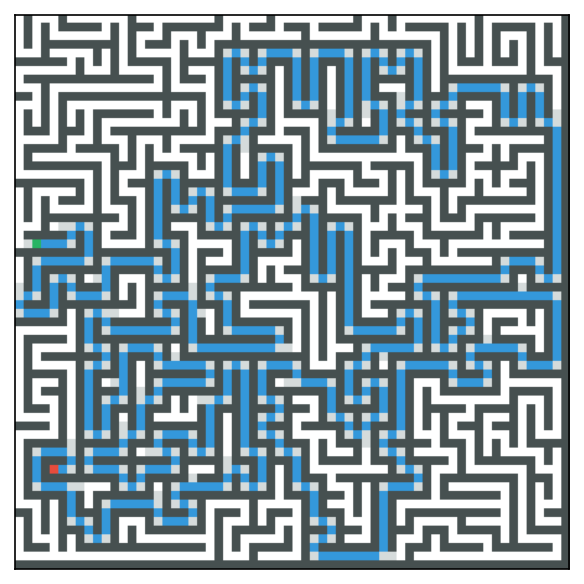

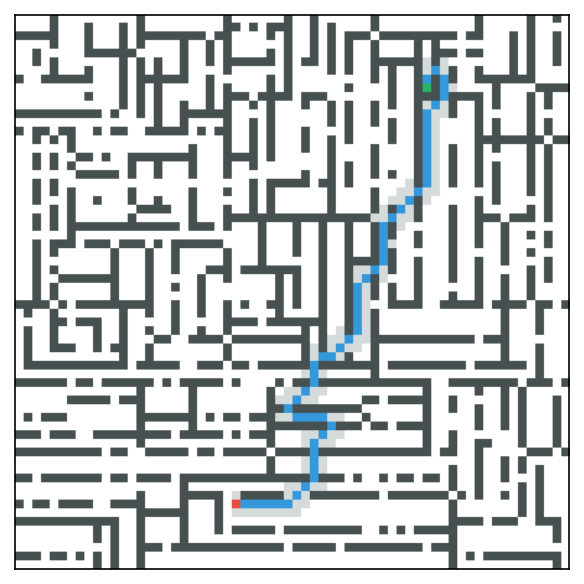

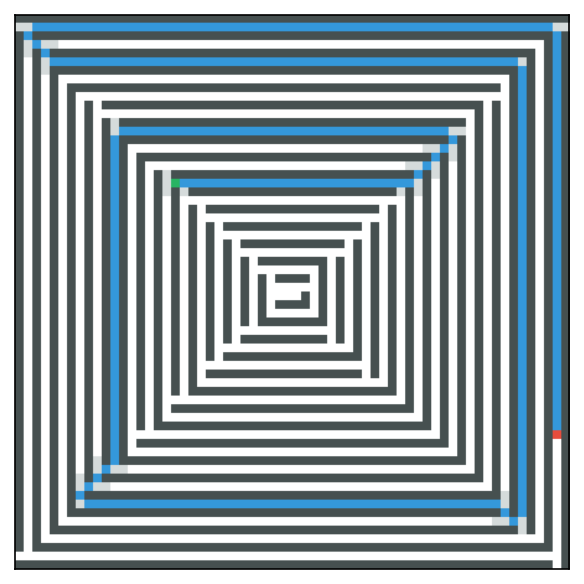

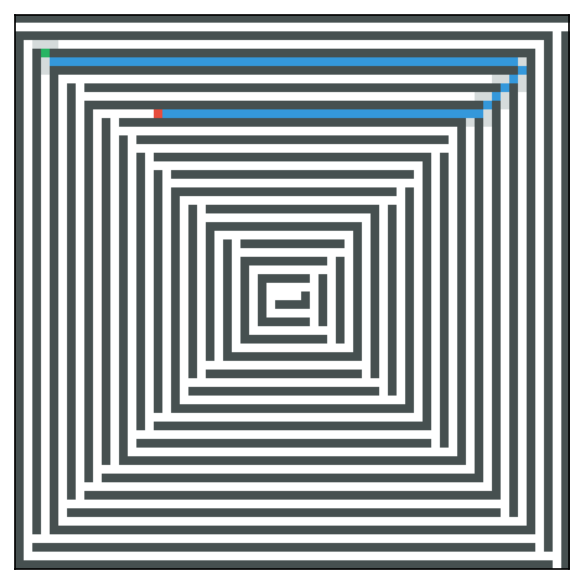

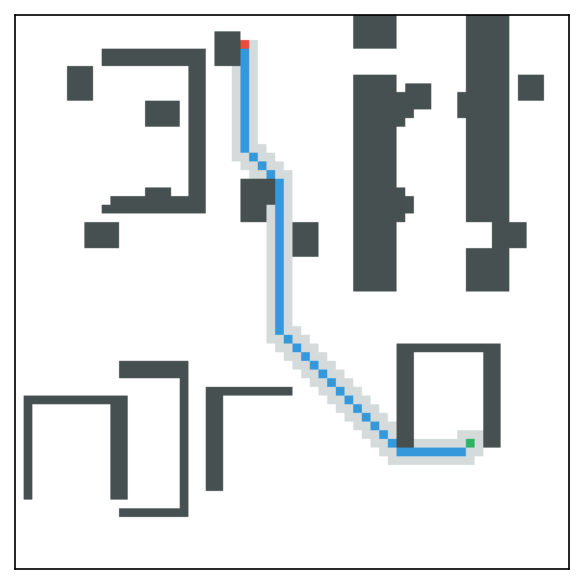

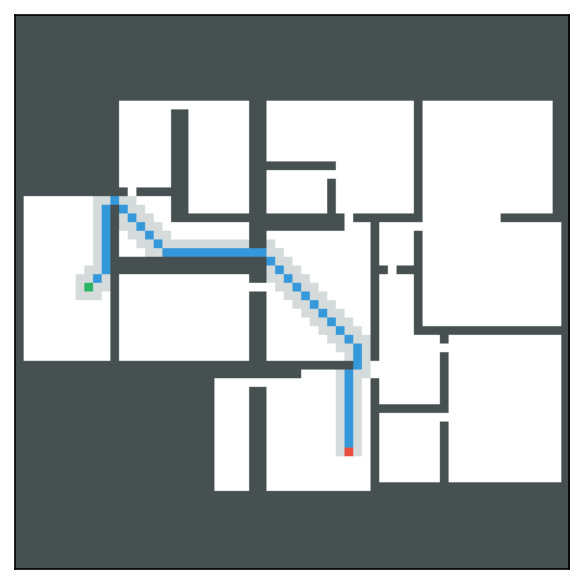

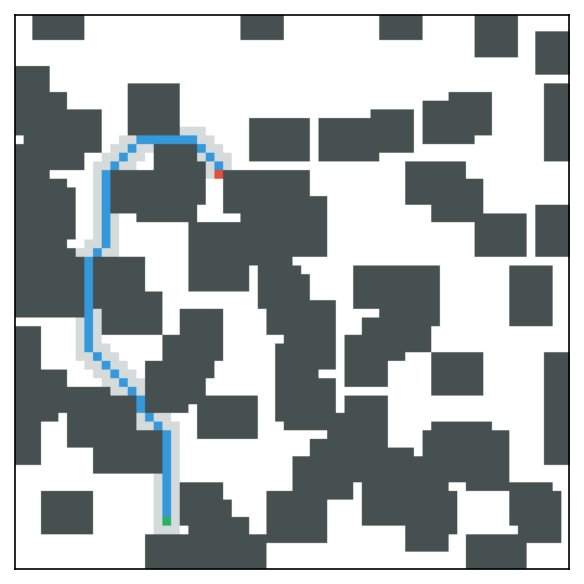

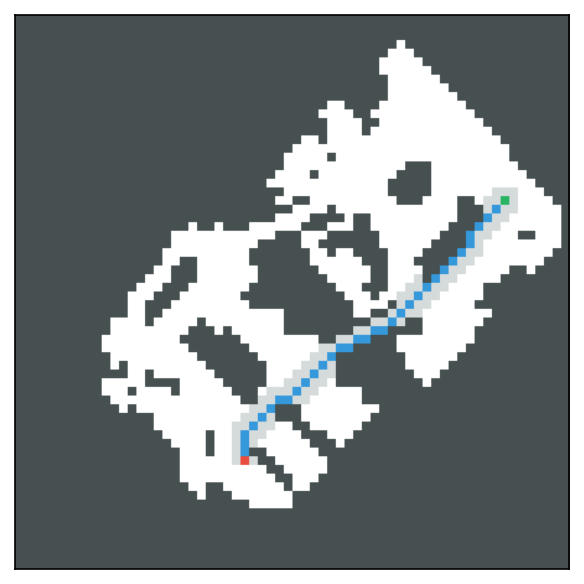

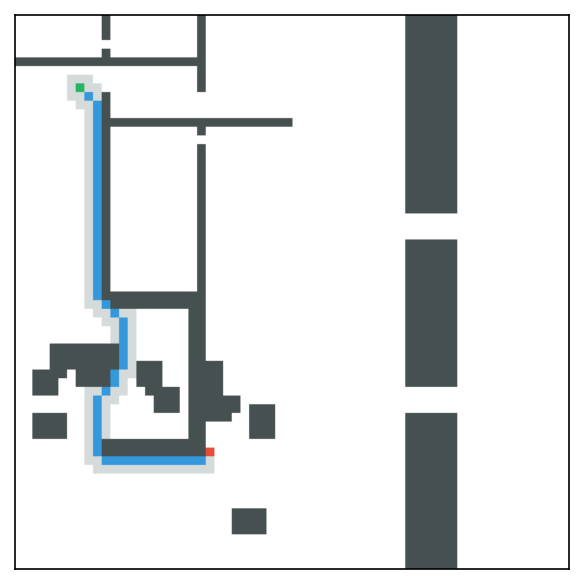

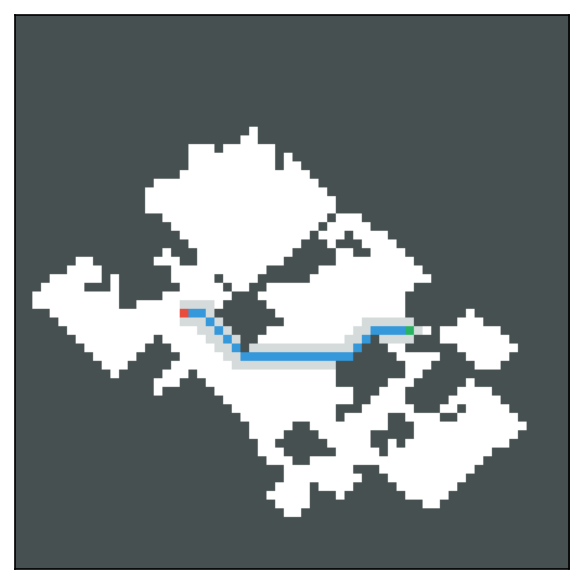

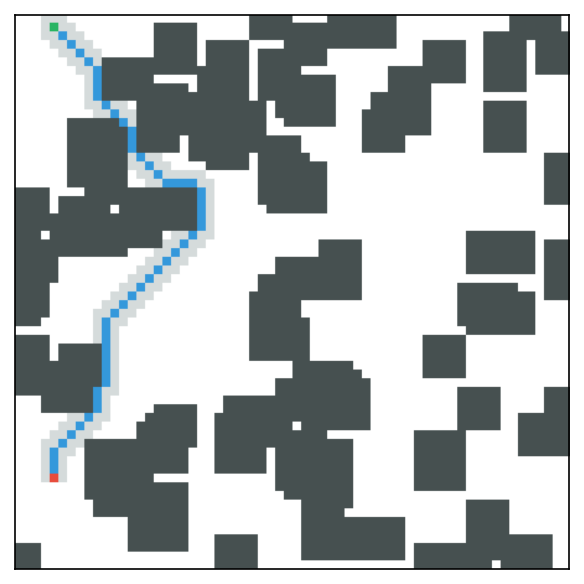

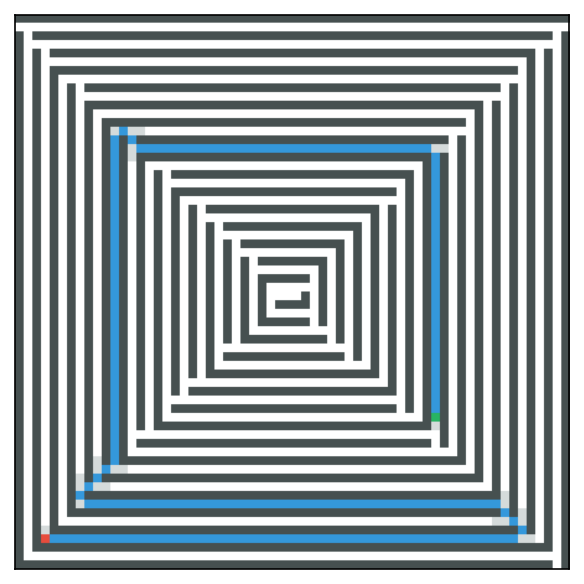

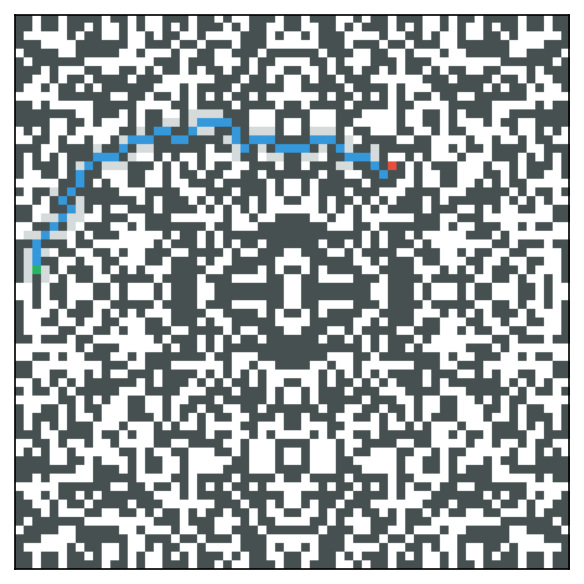

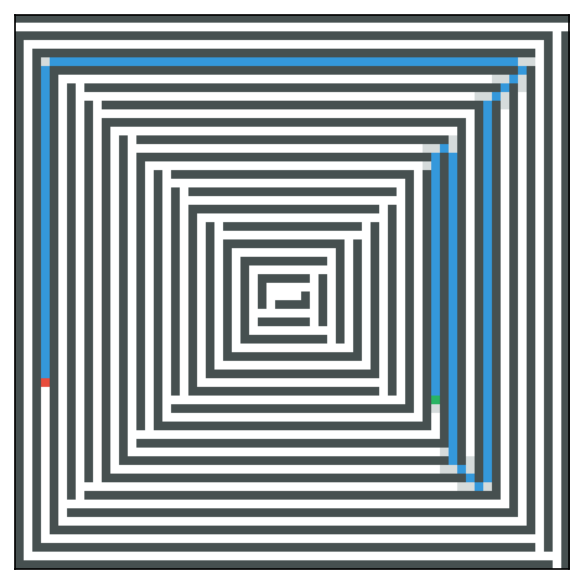

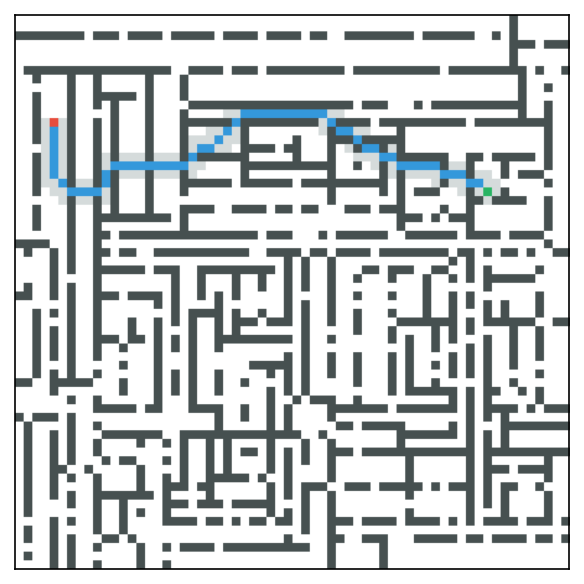

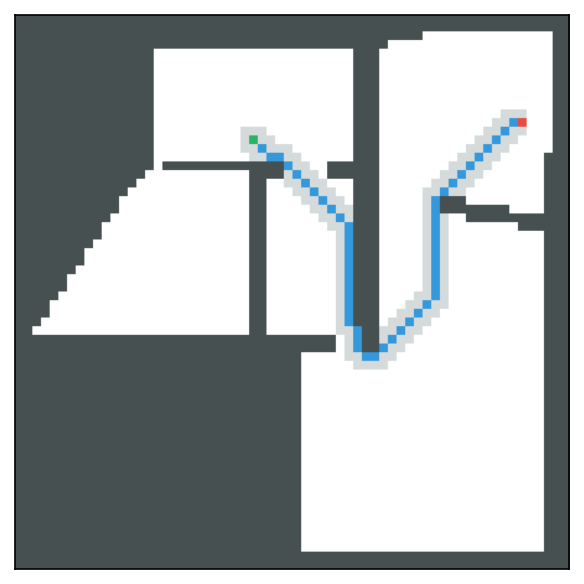

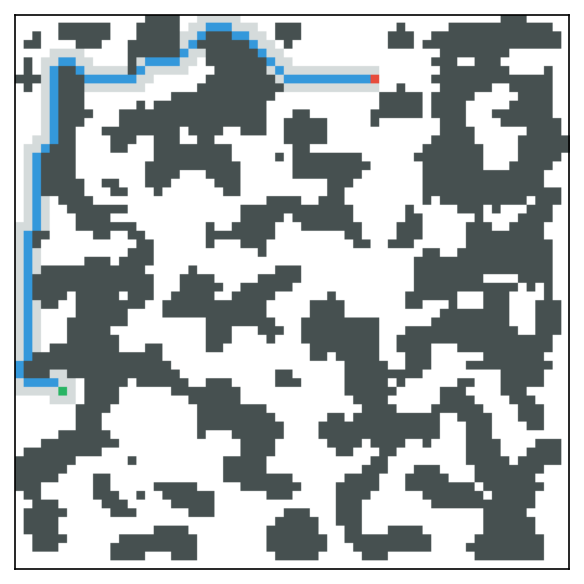

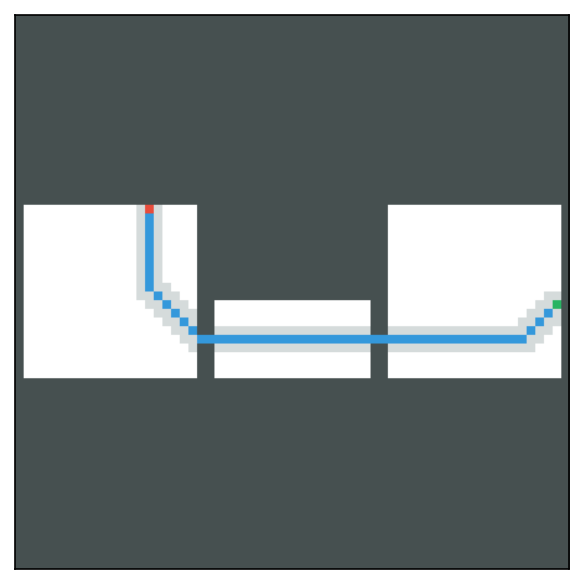

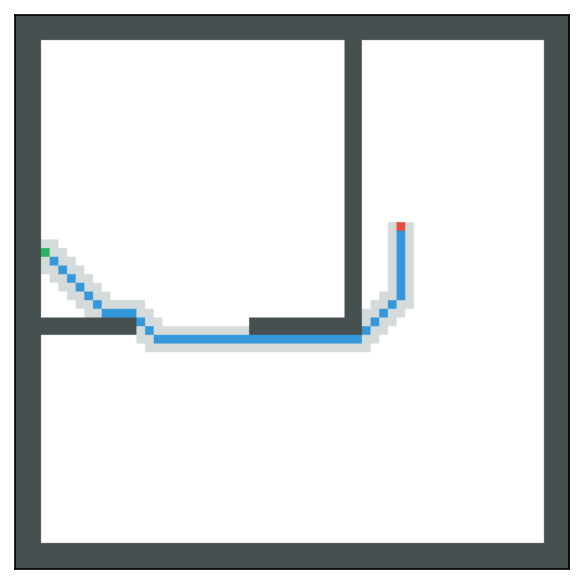

During the search was discovered 0 non-existent paths
CPU times: user 39.6 s, sys: 586 ms, total: 40.2 s
Wall time: 40 s


,index,path_length,expanded_nodes_num
0,0,674.239682,574
1,1,72.769553,62
2,2,386.698485,378
3,3,99.899495,97
4,4,62.870058,55
...,...,...,...
19995,19995,56.727922,53
19996,19996,435.629509,359
19997,19997,63.840620,51
19998,19998,48.041631,41


In [4]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test', cfs_filename='cf.npy')

idxes = np.arange(len(cells))
np.random.shuffle(idxes)

cells = cells[idxes]
starts = starts[idxes]
goals = goals[idxes]
cfs = cfs[idxes]

cfastar_octile_search(cells, starts, goals, cfs=cfs, node_type='optimal', verbose=20)

In [4]:
print('OPTIMAL TIE BREAK:')
print(f'Model expanded nodes num = {np.mean(res['model']['expanded_nodes_num'])}±{np.std(res['model']['expanded_nodes_num'])}')
print(f'WA* w=2 expanded nodes num = {np.mean(res['w=2']['expanded_nodes_num'])}±{np.std(res['w=2']['expanded_nodes_num'])}')
#print(f'WA* w=5 expanded nodes num = {np.mean(res['w=5']['expanded_nodes_num'])}±{np.std(res['w=5']['expanded_nodes_num'])}')
#print(f'WA* w=10 expanded nodes num = {np.mean(res['w=10']['expanded_nodes_num'])}±{np.std(res['w=10']['expanded_nodes_num'])}')

OPTIMAL TIE BREAK:
Model expanded nodes num = 0.7530891242083826±0.892770147661944
WA* w=2 expanded nodes num = 0.5356805115997163±0.3312112156757243


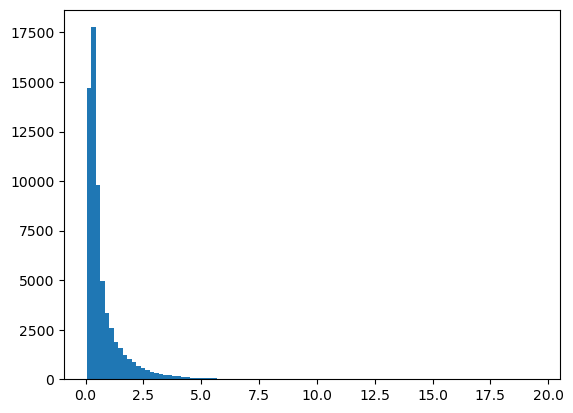

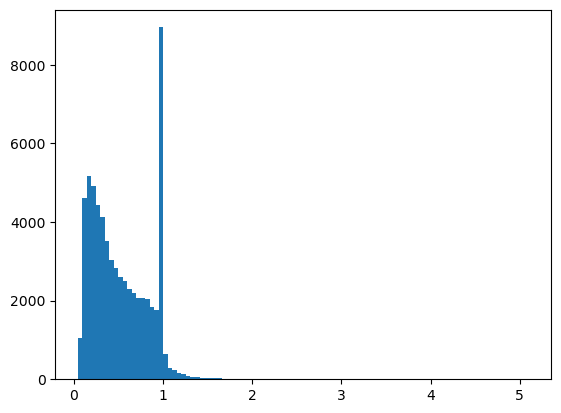

In [5]:
import matplotlib.pyplot as plt

plt.hist(res['model']['expanded_nodes_num'], bins=100)
plt.show()
plt.hist(res['w=2']['expanded_nodes_num'], bins=100)
plt.show()

A* octile search:   0%|          | 0/64000 [00:00<?, ?it/s]

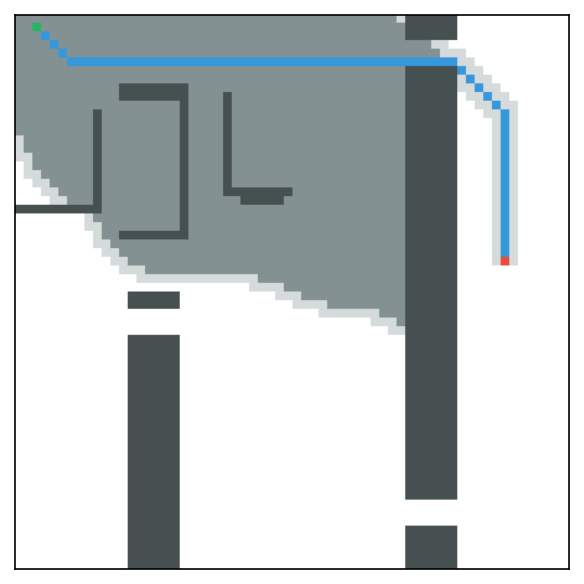

KeyboardInterrupt: 

In [10]:
cells, starts, goals, cfs = data_from_dir('../TransPath_data/test', cfs_filename='cf_predictions.npy')

res = contain_ratios(cells, starts, goals, ws=[2], cfs=cfs, node_type='anti-optimal', verbose=2)

In [8]:
print('ANTI-OPTIMAL TIE BREAK:')
print(f'Model expanded nodes num = {np.mean(res['model']['expanded_nodes_num'])}±{np.std(res['model']['expanded_nodes_num'])}')
print(f'WA* w=2 expanded nodes num = {np.mean(res['w=2']['expanded_nodes_num'])}±{np.std(res['w=2']['expanded_nodes_num'])}')
#print(f'WA* w=5 expanded nodes num = {np.mean(res['w=5']['expanded_nodes_num'])}±{np.std(res['w=5']['expanded_nodes_num'])}')
#print(f'WA* w=10 expanded nodes num = {np.mean(res['w=10']['expanded_nodes_num'])}±{np.std(res['w=10']['expanded_nodes_num'])}')

ANTI-OPTIMAL TIE BREAK:
Model expanded nodes num = 0.3033589228623355±0.1463454947713238
WA* w=2 expanded nodes num = 0.2908802383941506±0.1882760959527956


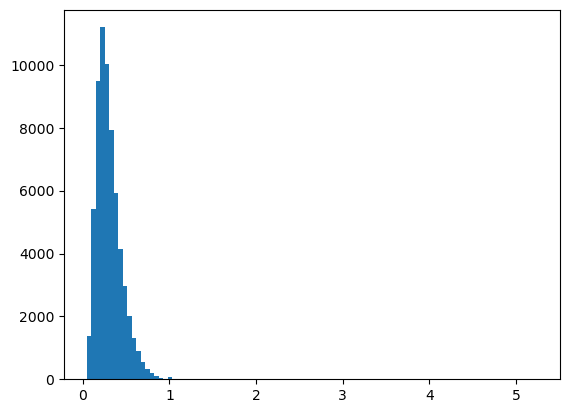

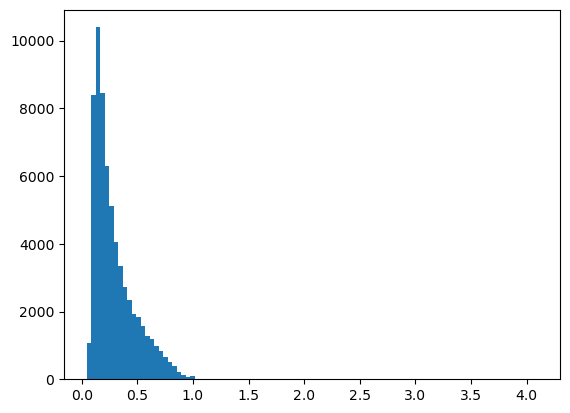

In [9]:
import matplotlib.pyplot as plt

plt.hist(res['model']['expanded_nodes_num'], bins=100)
plt.show()
plt.hist(res['w=2']['expanded_nodes_num'], bins=100)
plt.show()

A* octile search:   0%|          | 0/64000 [00:00<?, ?it/s]

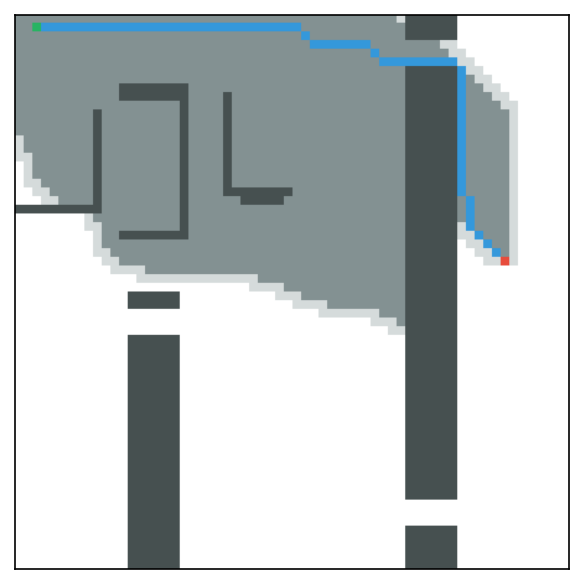

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



A* with cf octile search:   0%|          | 0/64000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:612: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


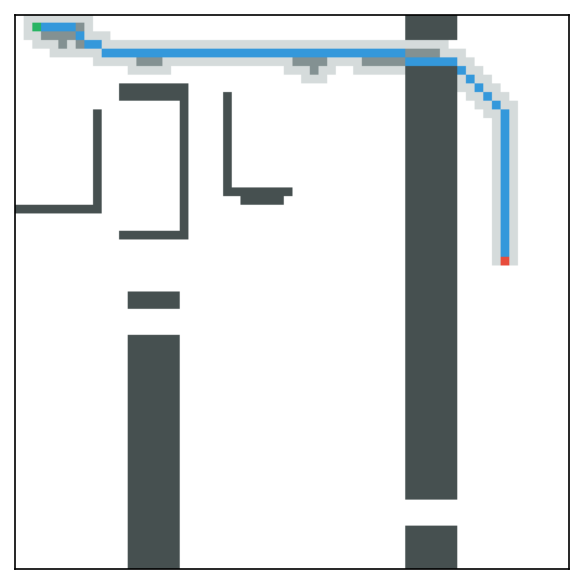

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* octile search:   0%|          | 0/64000 [00:00<?, ?it/s]

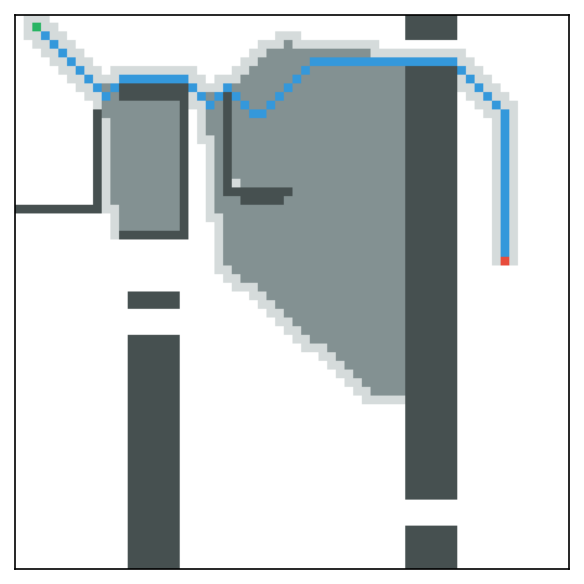

During the search was discovered 0 non-existent paths


In [4]:
cells, starts, goals, cfs = data_from_dir('../TransPath_data/test', cfs_filename='cf_predictions.npy')

res = contain_ratios(cells, starts, goals, ws=[2], cfs=cfs, node_type='anti-optimal', threshold=1.05, verbose=2)

In [5]:
print('ANTI-OPTIMAL TIE BREAK+1.05 FILTER:')
print(f'Model expanded nodes num = {np.mean(res['model']['expanded_nodes_num'])}±{np.std(res['model']['expanded_nodes_num'])}')
print(f'WA* w=2 expanded nodes num = {np.mean(res['w=2']['expanded_nodes_num'])}±{np.std(res['w=2']['expanded_nodes_num'])}')
#print(f'WA* w=5 expanded nodes num = {np.mean(res['w=5']['expanded_nodes_num'])}±{np.std(res['w=5']['expanded_nodes_num'])}')
#print(f'WA* w=10 expanded nodes num = {np.mean(res['w=10']['expanded_nodes_num'])}±{np.std(res['w=10']['expanded_nodes_num'])}')

ANTI-OPTIMAL TIE BREAK+1.05 FILTER:
Model expanded nodes num = 0.26671401459213484±0.12525655756369636
WA* w=2 expanded nodes num = 0.34513160429290424±0.1999605411940759


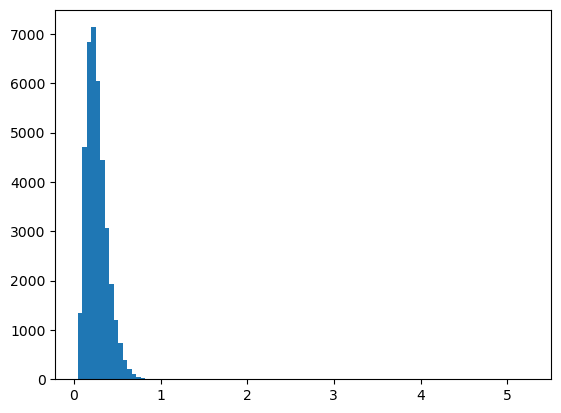

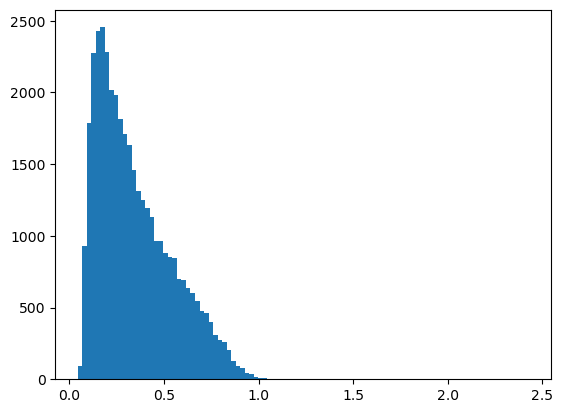

In [6]:
import matplotlib.pyplot as plt

plt.hist(res['model']['expanded_nodes_num'], bins=100)
plt.show()
plt.hist(res['w=2']['expanded_nodes_num'], bins=100)
plt.show()

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

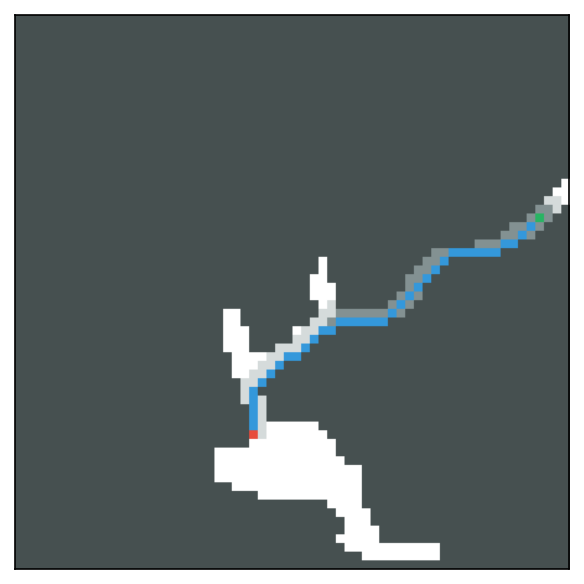

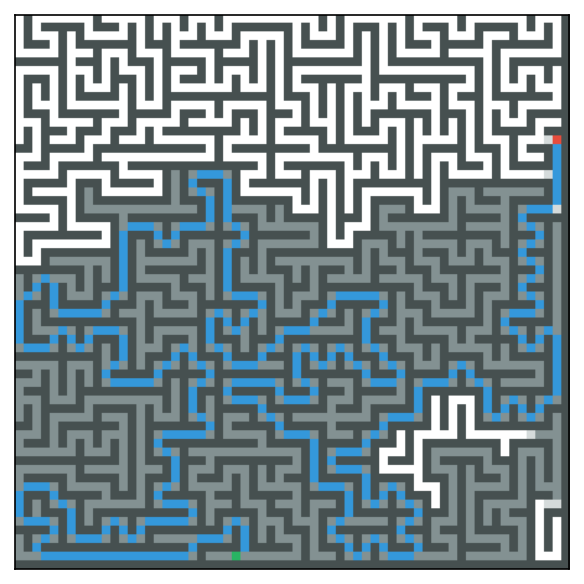

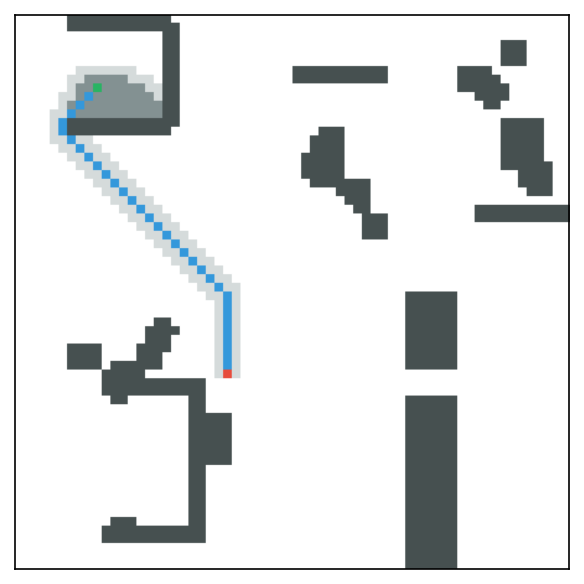

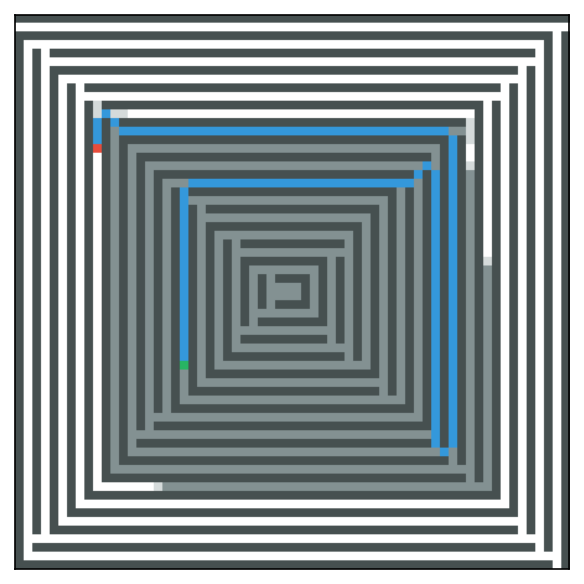

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


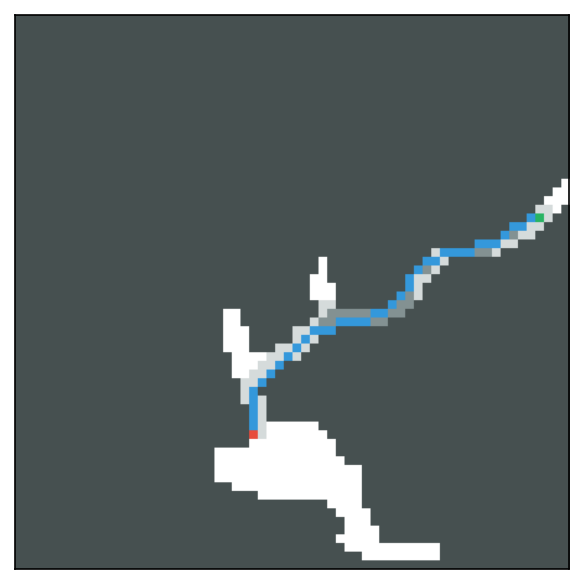

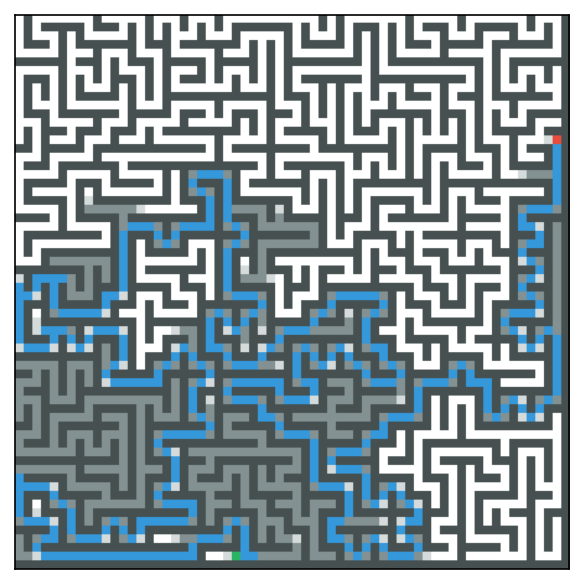

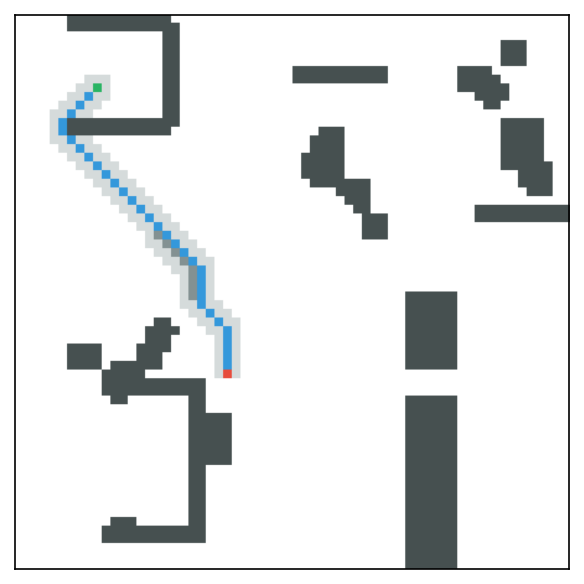

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


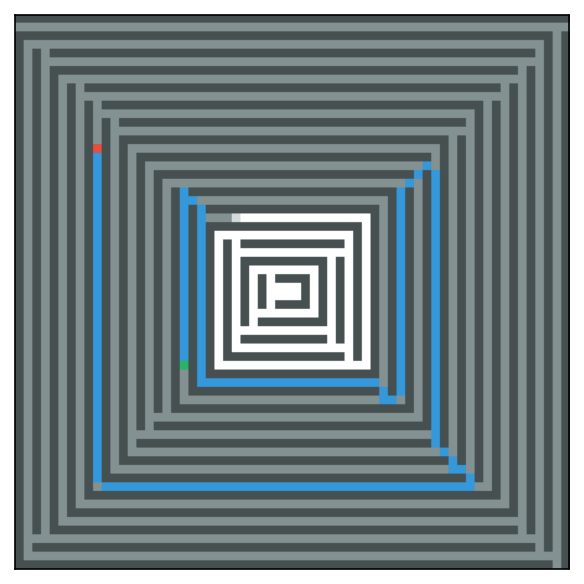

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/9 [00:00<?, ?it/s]

WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

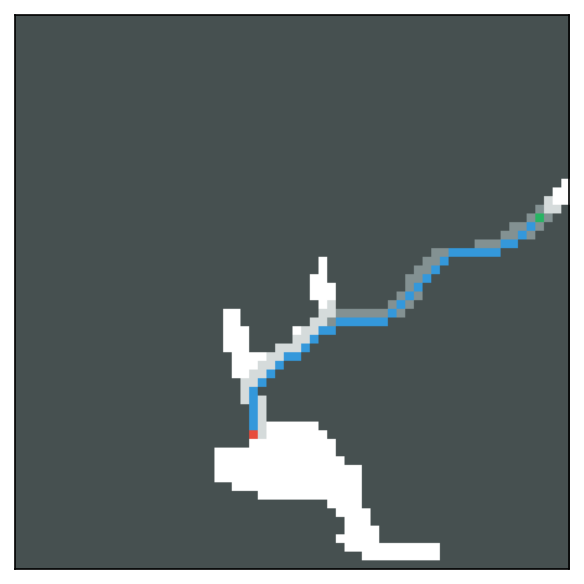

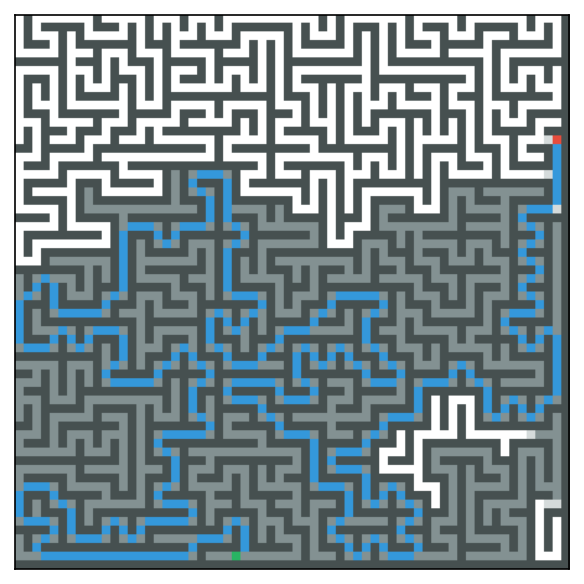

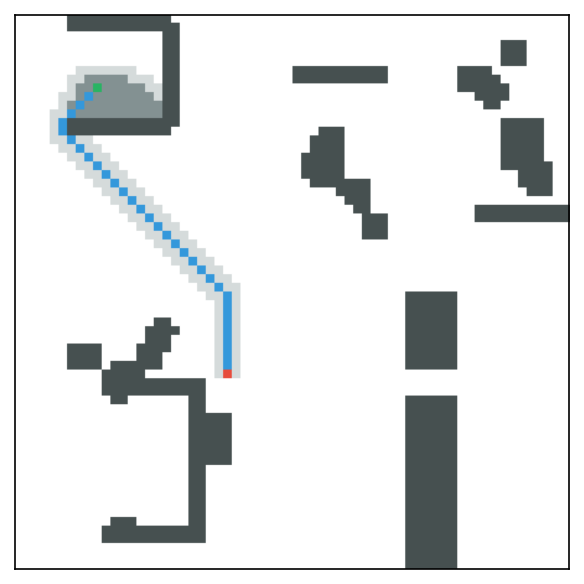

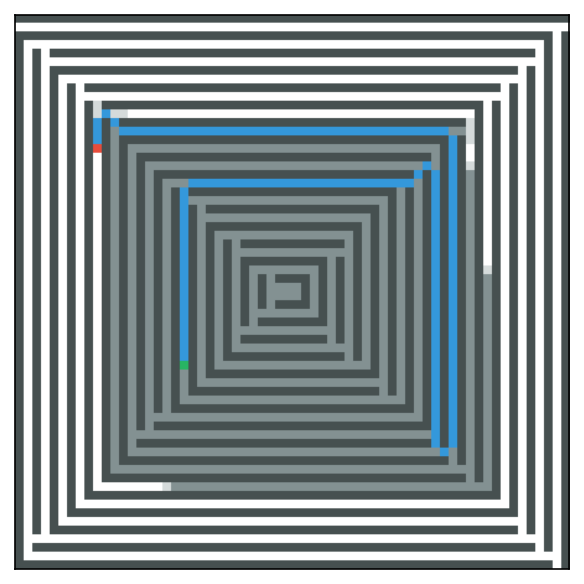

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

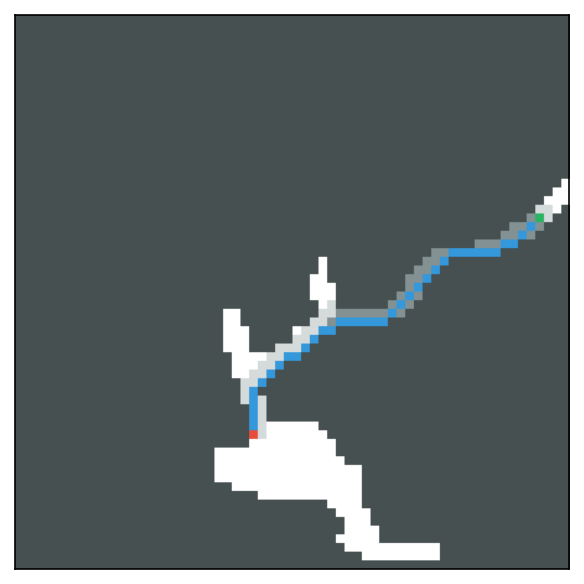

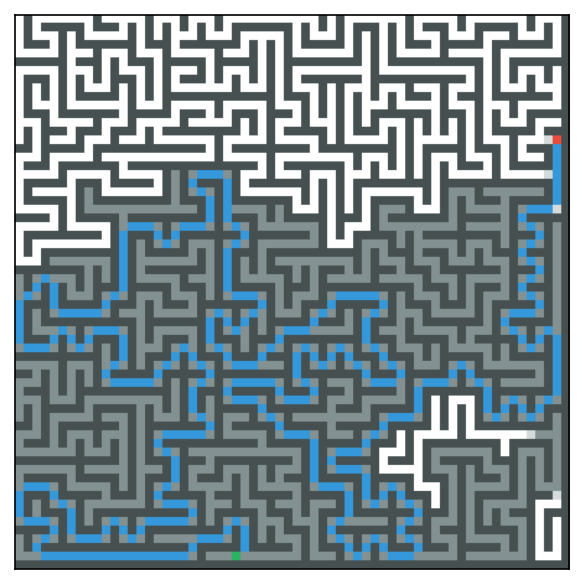

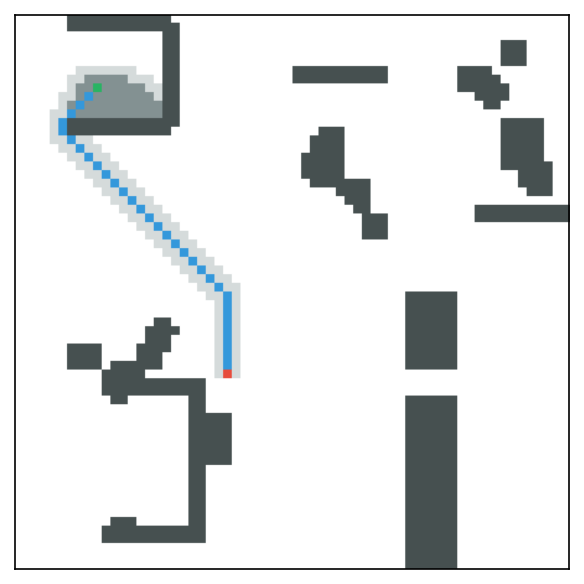

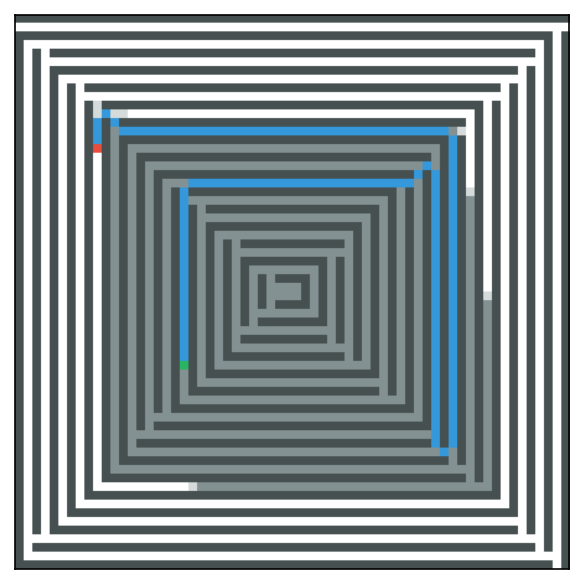

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

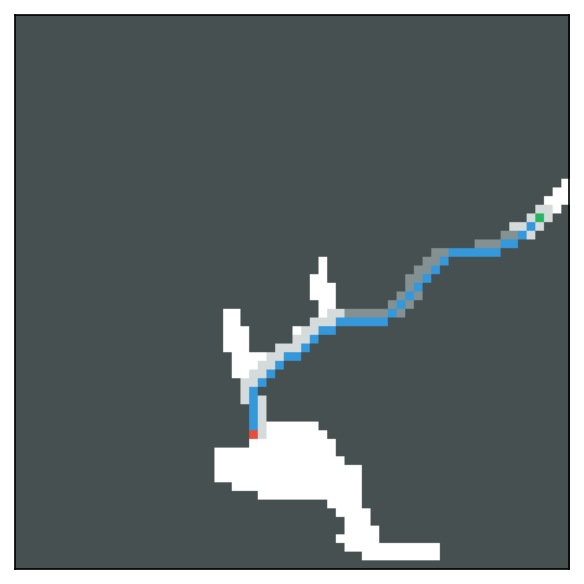

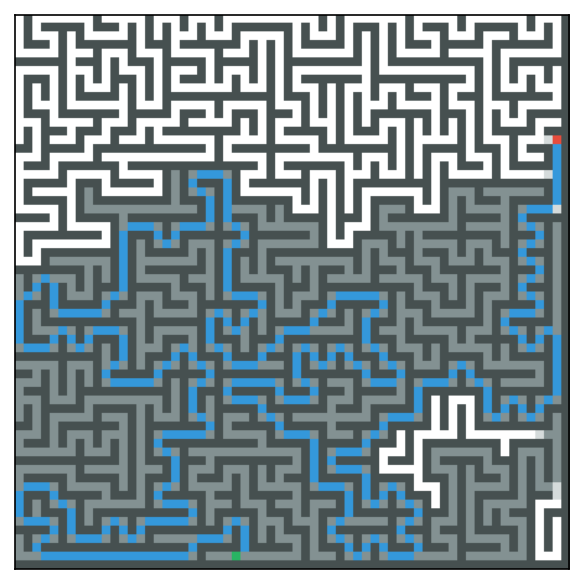

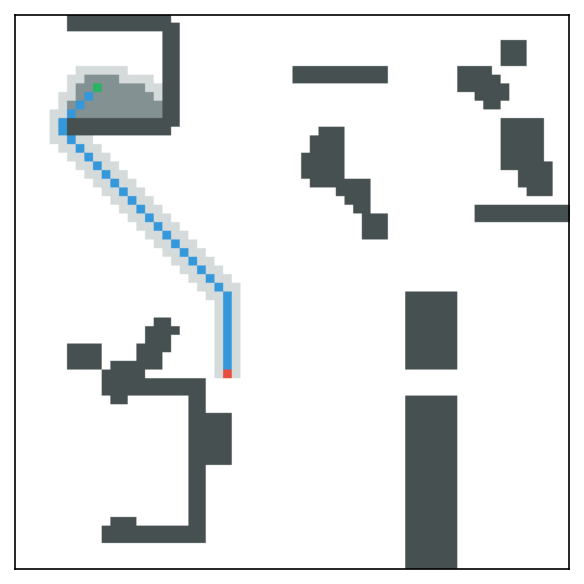

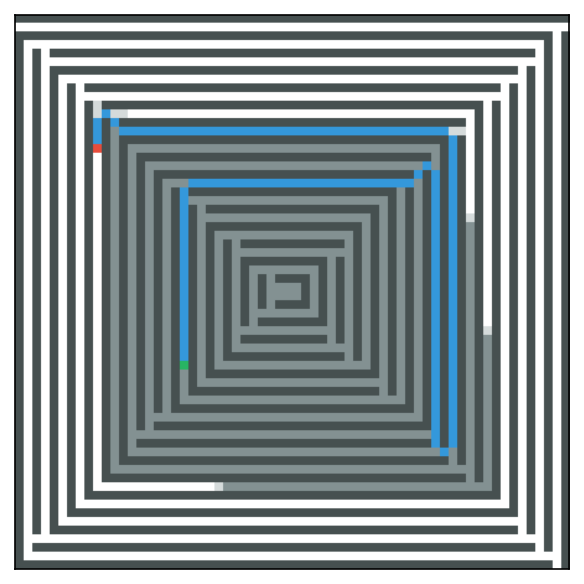

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

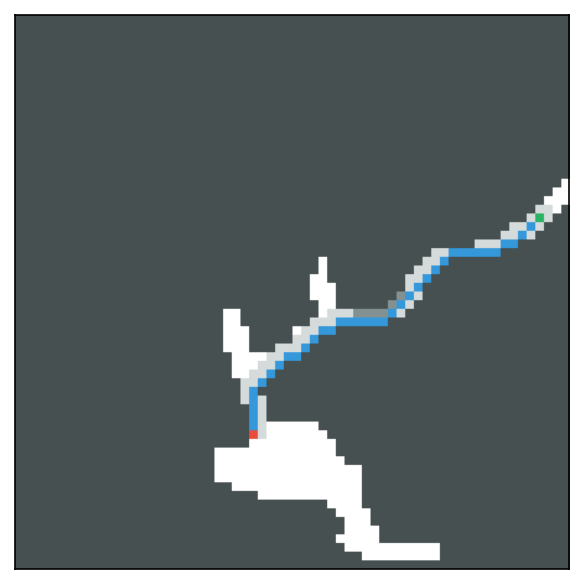

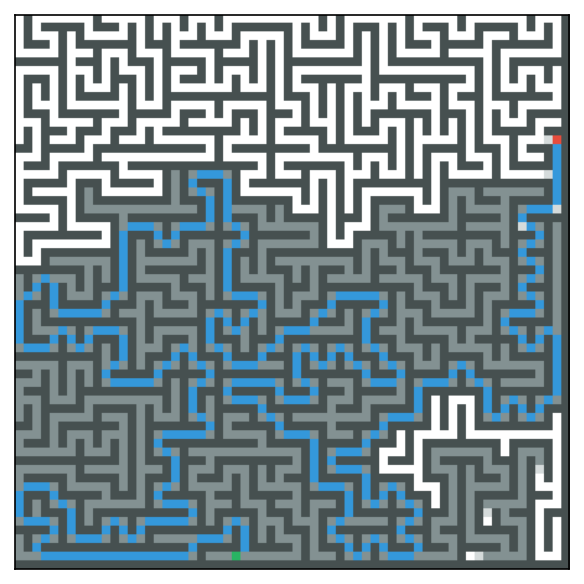

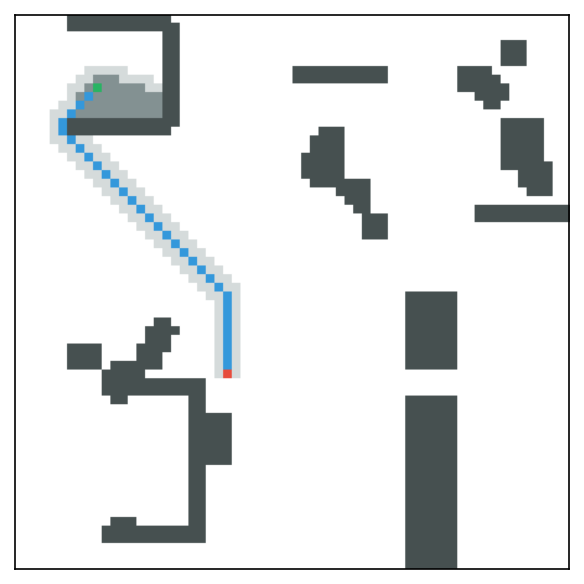

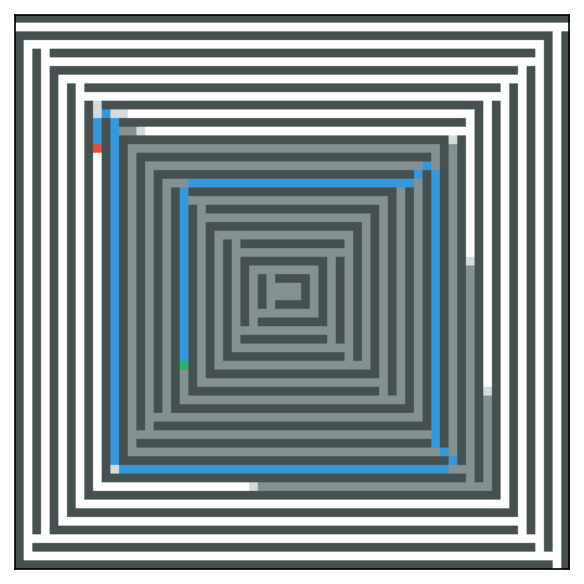

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

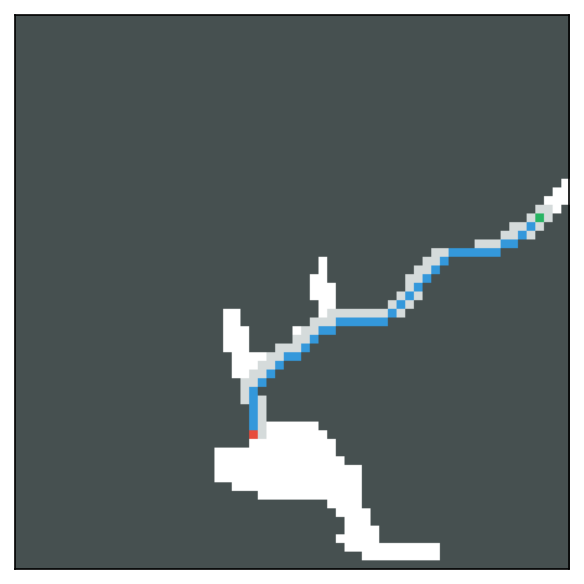

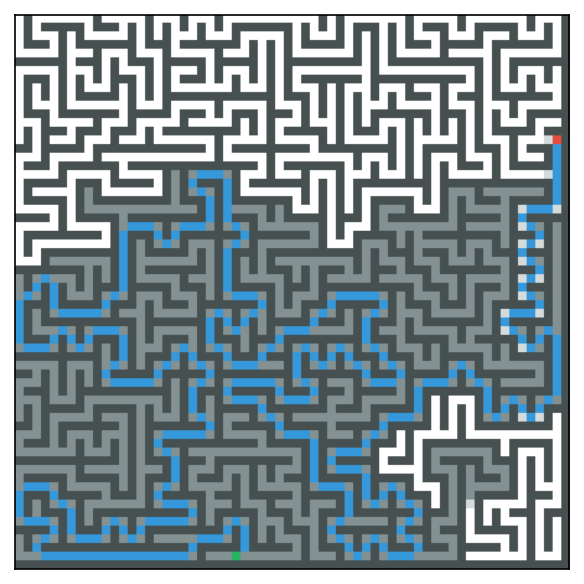

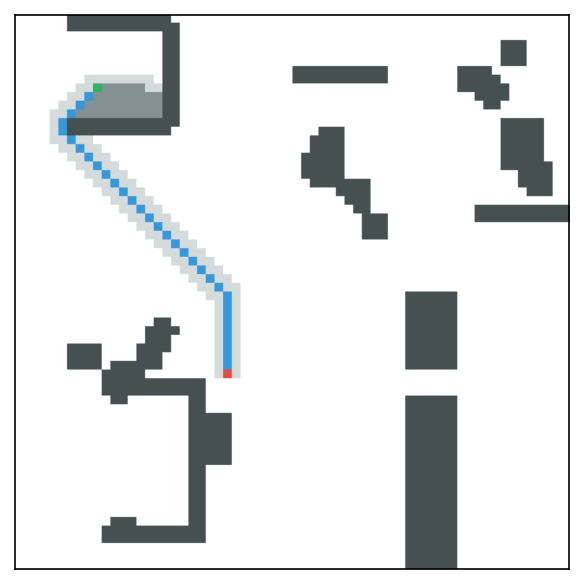

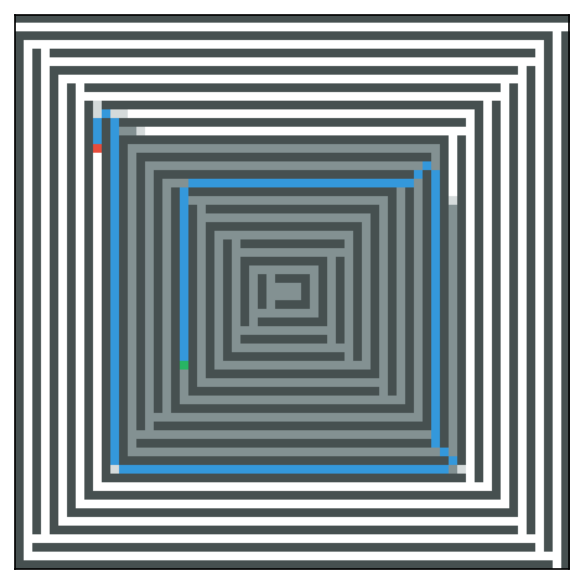

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

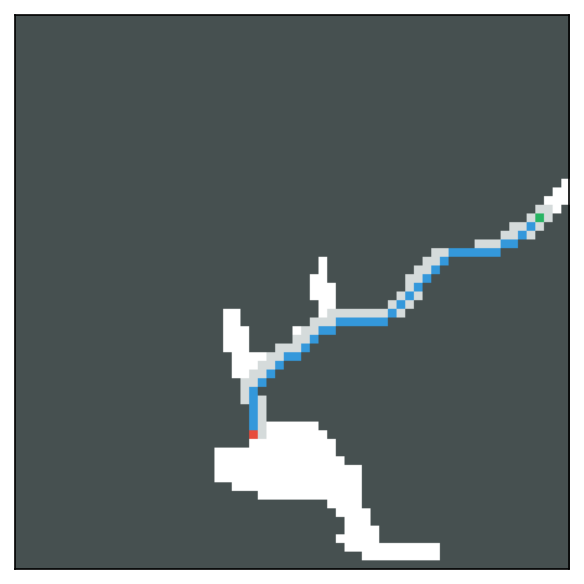

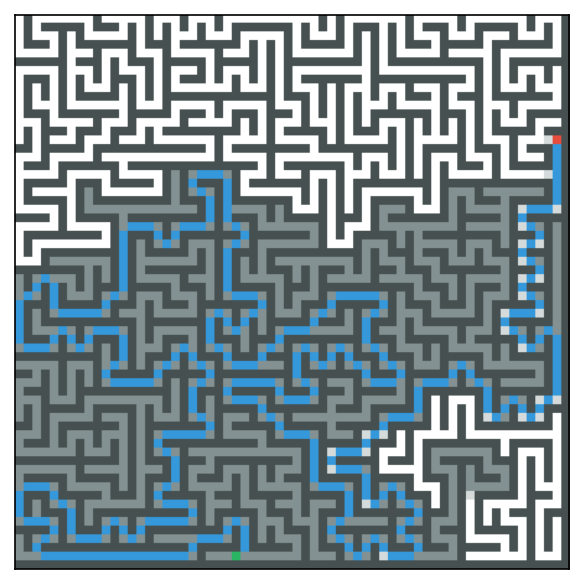

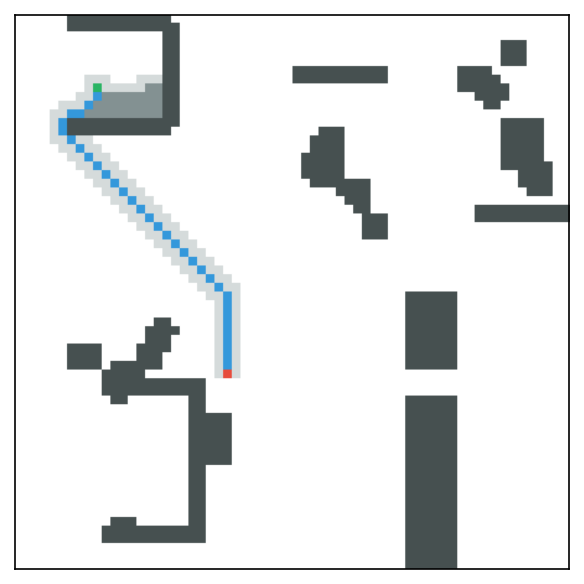

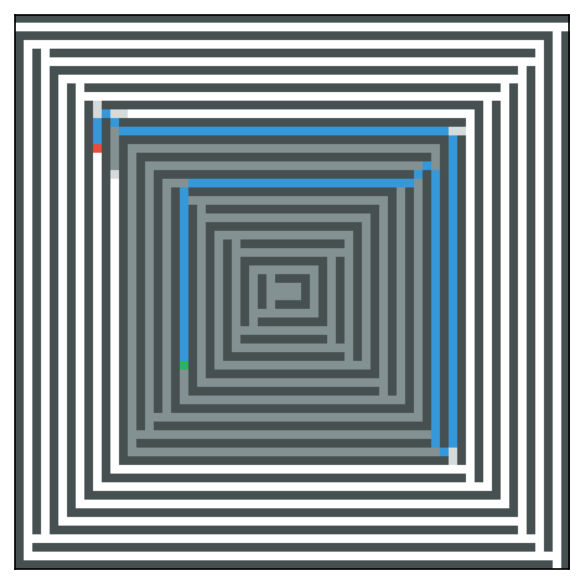

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

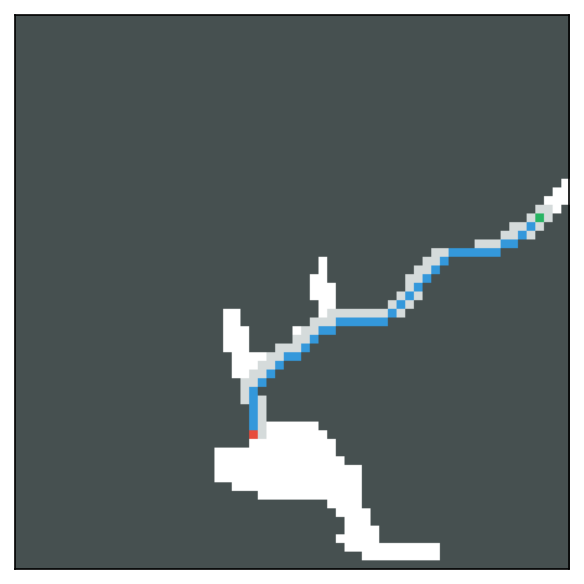

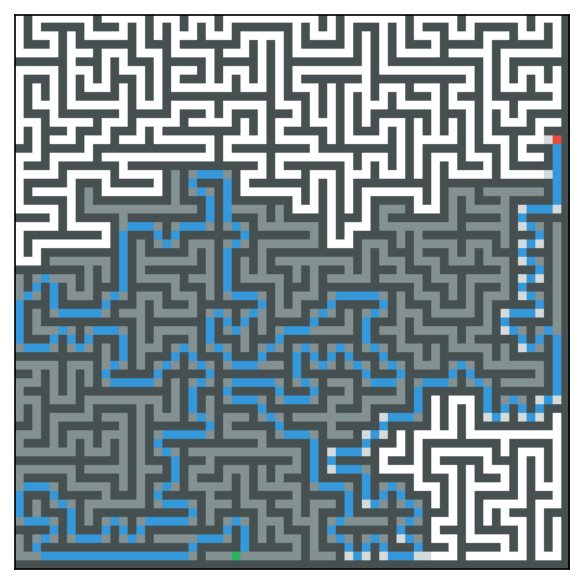

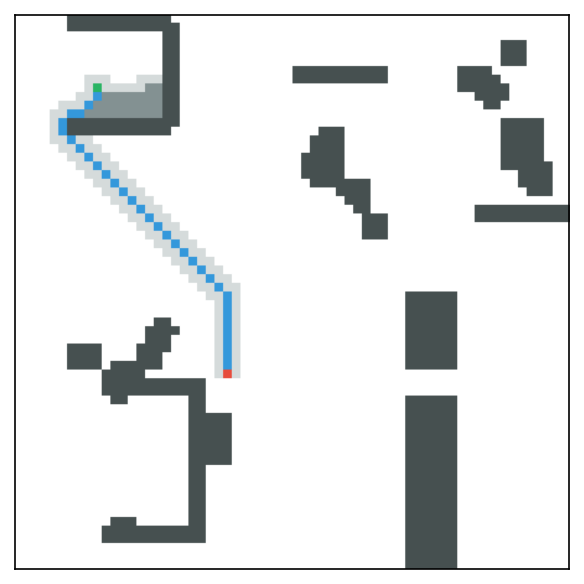

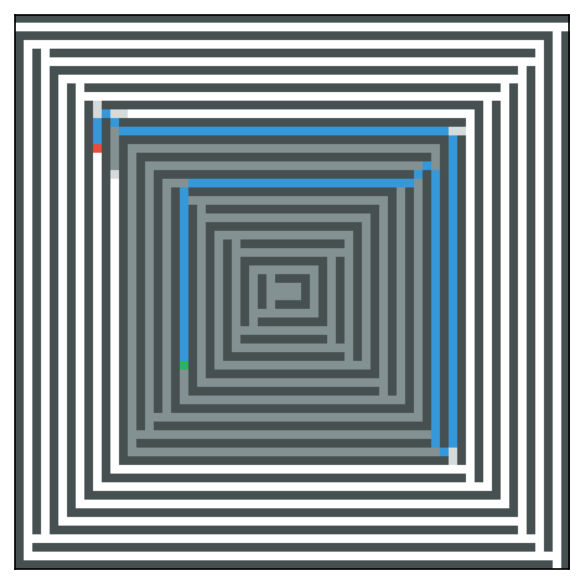

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

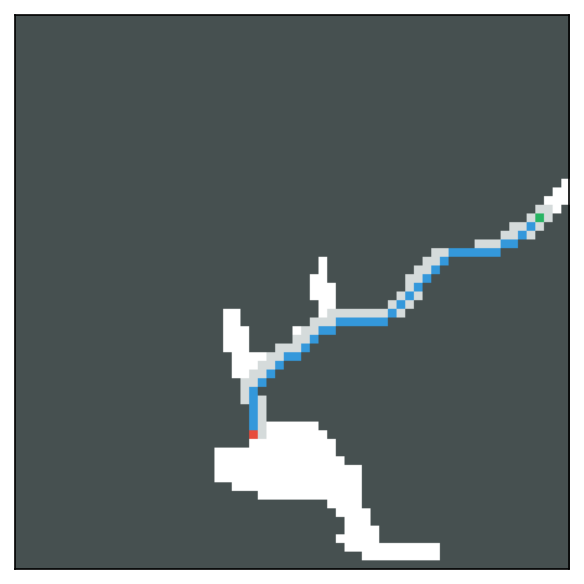

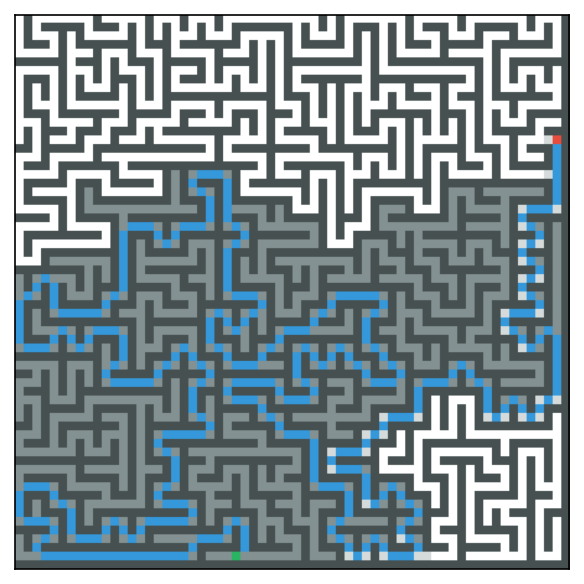

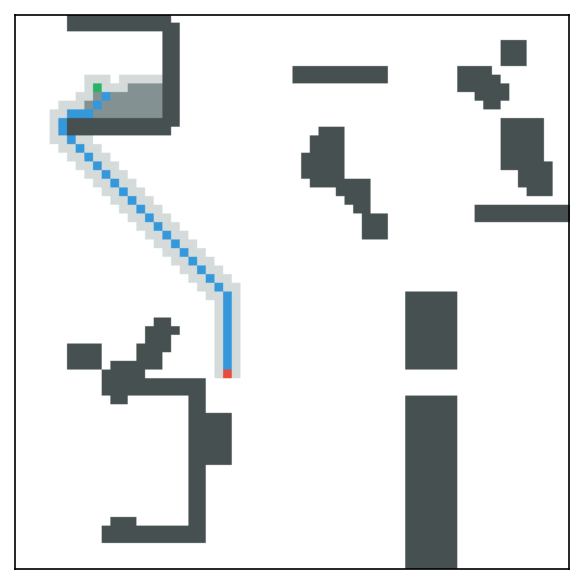

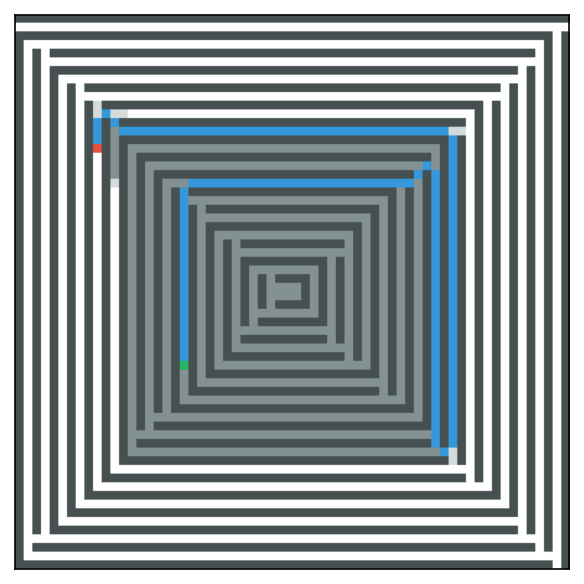

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

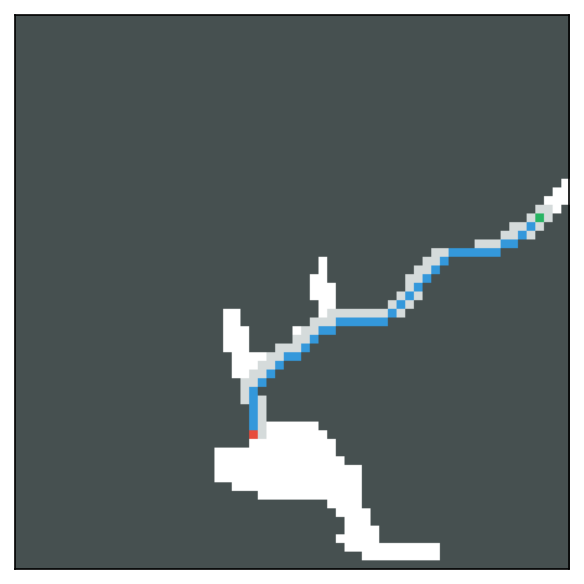

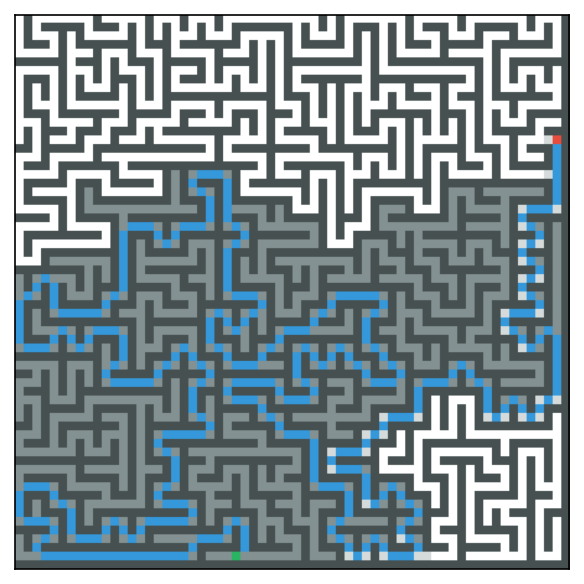

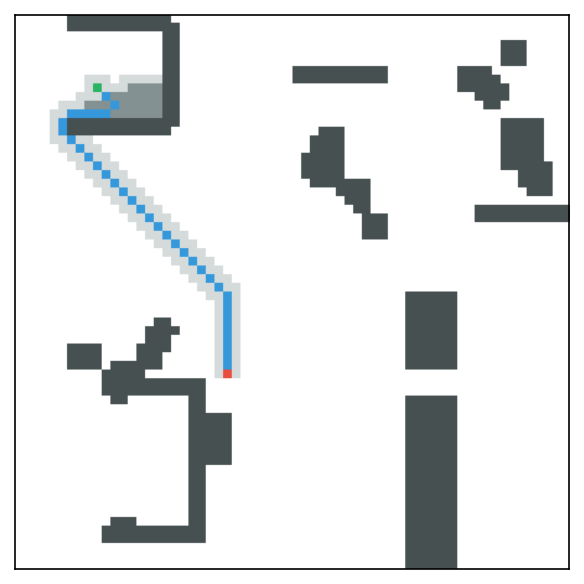

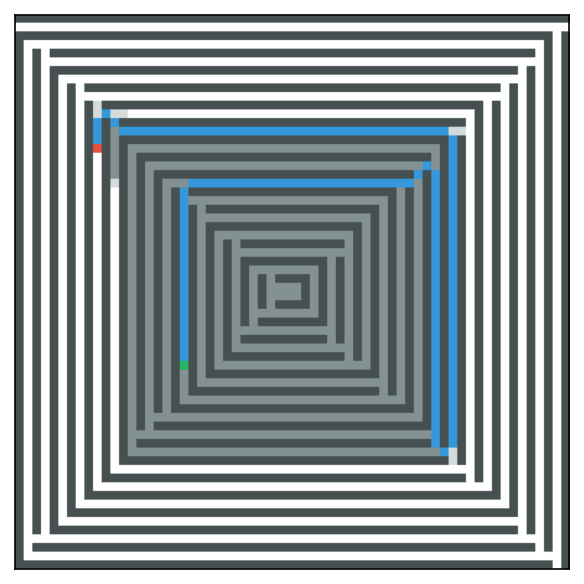

During the search was discovered 0 non-existent paths
CPU times: user 34min 57s, sys: 14.8 s, total: 35min 12s
Wall time: 34min 42s


In [6]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test')

idxes = np.arange(len(cells))
np.random.shuffle(idxes)

cells = cells[idxes]
starts = starts[idxes]
goals = goals[idxes]

model = create_TransPath_model(weights_path='../weights/gold_cf_model', device='cuda:0')

res = contain_ratios(cells, starts, goals, ws=[1.01, 1.05, 1.1, 1.25, 2, 3, 4, 5, 10], model=model, node_type='optimal', threshold=1.05, verbose=5)

In [8]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMAL1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [9]:
import pickle



# Save to a pickle file
with open("../results/OPTIMAL1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model,w=1.01,w=1.05,w=1.1,w=1.25,w=2,w=3,w=4,w=5,w=10
Optimal found ratio,100.0%,32.34%,99.86%,96.12%,86.22%,63.04%,32.35%,24.13%,19.44%,14.38%,13.4%
Length ratio,100.0±0.0%,125.85±49.68%,100.0±0.01%,100.04±0.22%,100.2±0.58%,100.89±1.57%,103.74±4.85%,105.21±6.54%,106.77±7.92%,107.9±8.92%,109.72±11.08%
Expansions ratio,100.0±0.0%,111.42±134.28%,99.07±1.65%,93.07±8.93%,86.2±15.52%,72.63±24.6%,54.57±30.05%,49.79±30.08%,48.26±29.97%,47.25±29.79%,45.11±29.19%


In [8]:
print('OPTIMAL TIE BREAK+1.05 FILTER:')
print(f'Model expanded nodes num = {np.mean(res['model']['expanded_nodes_num'])}±{np.std(res['model']['expanded_nodes_num'])}')
print(f'WA* w=2 expanded nodes num = {np.mean(res['w=2']['expanded_nodes_num'])}±{np.std(res['w=2']['expanded_nodes_num'])}')
#print(f'WA* w=5 expanded nodes num = {np.mean(res['w=5']['expanded_nodes_num'])}±{np.std(res['w=5']['expanded_nodes_num'])}')
#print(f'WA* w=10 expanded nodes num = {np.mean(res['w=10']['expanded_nodes_num'])}±{np.std(res['w=10']['expanded_nodes_num'])}')

OPTIMAL TIE BREAK+1.05 FILTER:
Model expanded nodes num = 0.37030515447701096±0.2974022653099484
WA* w=2 expanded nodes num = 0.44271119334398945±0.2597863220773423


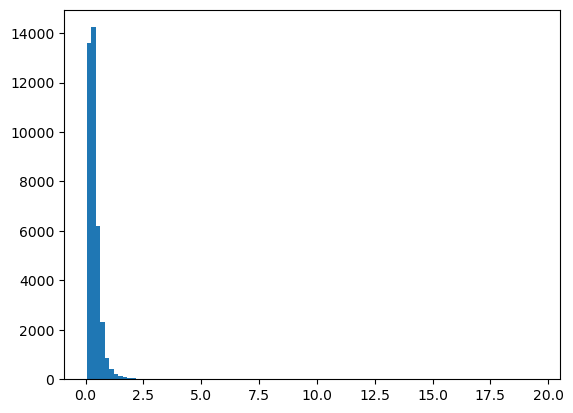

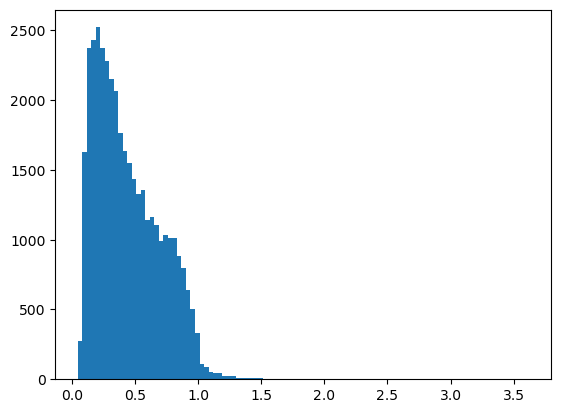

In [9]:
import matplotlib.pyplot as plt

plt.hist(res['model']['expanded_nodes_num'], bins=100)
plt.show()
plt.hist(res['w=2']['expanded_nodes_num'], bins=100)
plt.show()

In [10]:
print(len(res['model']) / len(cells))

0.597796875


In [11]:
print(len(res['model']))

38259


A* octile search:   0%|          | 0/64000 [00:00<?, ?it/s]

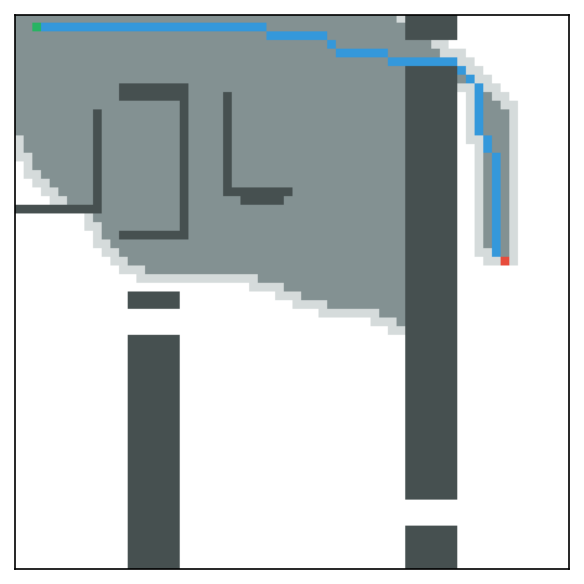

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



A* with cf octile search:   0%|          | 0/64000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:612: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


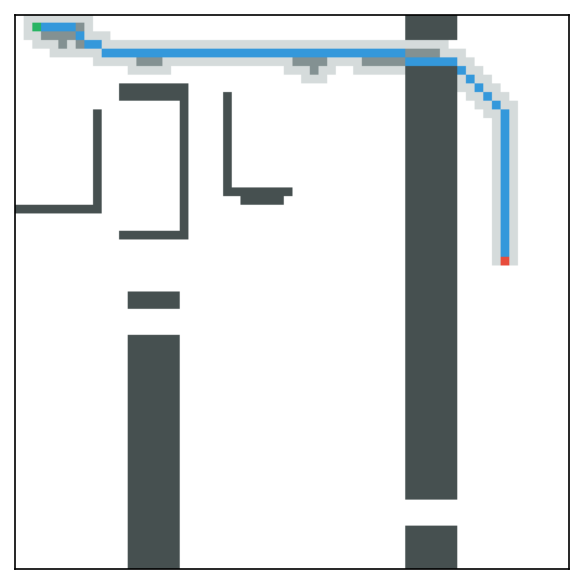

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* octile search:   0%|          | 0/64000 [00:00<?, ?it/s]

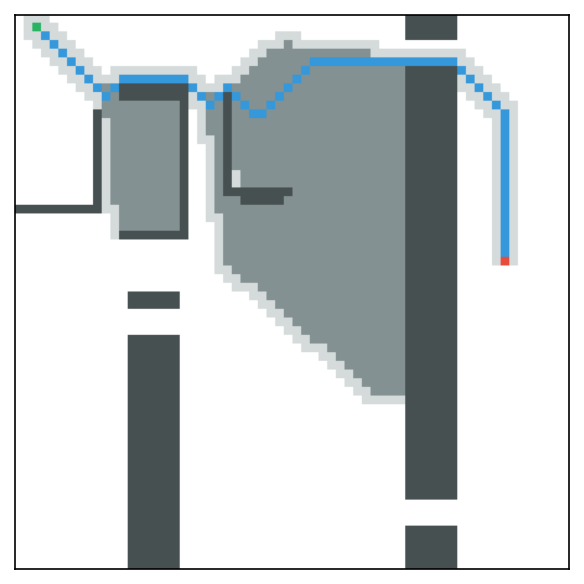

During the search was discovered 0 non-existent paths


In [12]:
cells, starts, goals, cfs = data_from_dir('../TransPath_data/test', cfs_filename='cf_predictions.npy')

res = contain_ratios(cells, starts, goals, ws=[2], cfs=cfs, node_type='other', threshold=1.05, verbose=2)

In [13]:
print('NO TIE BREAK+1.05 FILTER:')
print(f'Model expanded nodes num = {np.mean(res['model']['expanded_nodes_num'])}±{np.std(res['model']['expanded_nodes_num'])}')
print(f'WA* w=2 expanded nodes num = {np.mean(res['w=2']['expanded_nodes_num'])}±{np.std(res['w=2']['expanded_nodes_num'])}')
#print(f'WA* w=5 expanded nodes num = {np.mean(res['w=5']['expanded_nodes_num'])}±{np.std(res['w=5']['expanded_nodes_num'])}')
#print(f'WA* w=10 expanded nodes num = {np.mean(res['w=10']['expanded_nodes_num'])}±{np.std(res['w=10']['expanded_nodes_num'])}')

NO TIE BREAK+1.05 FILTER:
Model expanded nodes num = 0.3194987376311495±0.19731315970096772
WA* w=2 expanded nodes num = 0.3963038899088885±0.22627928810294148


In [14]:
print('NO TIE BREAK+1.05 FILTER:')
print(f'Model expanded nodes num = {np.round(np.mean(res['model']['expanded_nodes_num']) * 100, 2)}±{np.round(np.std(res['model']['expanded_nodes_num']) * 100, 2)}')
print(f'WA* w=2 expanded nodes num = {np.round(np.mean(res['w=2']['expanded_nodes_num']) * 100, 2)}±{np.round(np.std(res['w=2']['expanded_nodes_num']) * 100, 2)}')

NO TIE BREAK+1.05 FILTER:
Model expanded nodes num = 31.95±19.73
WA* w=2 expanded nodes num = 39.63±22.63
